Generating Multi-Split Comparison Table...

Table 1: Accuracy Comparison with Different Training/Testing Sets
Split Ratio             A=75%, B=25%  A=70%, B=30%  A=80%, B=20%
Decision Tree                  0.982         0.985         0.985
K-Nearest Neighbors            0.955         0.957         0.960
Support Vector Machine         0.974         0.975         0.978
Random Forest                  0.989         0.991         0.992
AdaBoost                       0.969         0.966         0.963

Table 2: Impact of Hyperparameters on Random Forest
--------------------------------------------------
RF (Default)              | Accuracy: 99.30%
RF (Tuned - 100 Trees)    | Accuracy: 99.10%
RF (Tuned - Max Depth 5)  | Accuracy: 98.50%


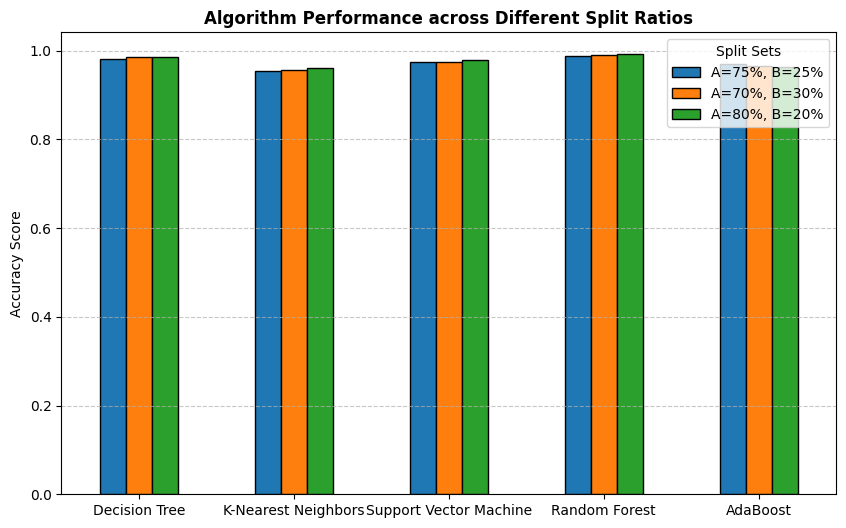

In [1]:
# ============================================================
# PROJECT: BANK LOAN PREDICTION (JETIR STYLE COMPARISON)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Load Data
df = pd.read_csv('/content/bankloan.csv')
X = df.drop(['ID', 'ZIP.Code', 'Personal.Loan'], axis=1)
y = df['Personal.Loan']

# ------------------------------------------------------------
# PART A: MULTIPLE SPLIT RATIO COMPARISON (JETIR STYLE)
# ------------------------------------------------------------
# A = Training %, B = Testing %
splits = [(0.25, "A=75%, B=25%"), (0.30, "A=70%, B=30%"), (0.20, "A=80%, B=20%")]

models_basic = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42)
}

split_table = []

print("Generating Multi-Split Comparison Table...")
for test_size, label in splits:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    row_results = {"Split Ratio": label}
    for name, model in models_basic.items():
        model.fit(X_train_s, y_train)
        acc = accuracy_score(y_test, model.predict(X_test_s))
        row_results[name] = round(acc, 3)
    split_table.append(row_results)

# JETIR Format Table Print
df_splits = pd.DataFrame(split_table).set_index("Split Ratio").T
print("\nTable 1: Accuracy Comparison with Different Training/Testing Sets")
print("="*80)
print(df_splits)
print("="*80)

# ------------------------------------------------------------
# PART B: HYPERPARAMETER TUNING EXAMPLE (FOR VIVA/PPT)
# ------------------------------------------------------------
# Hum Random Forest ke different parameters check karte hain
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

hp_configs = [
    {"name": "RF (Default)", "model": RandomForestClassifier(n_estimators=10, random_state=42)},
    {"name": "RF (Tuned - 100 Trees)", "model": RandomForestClassifier(n_estimators=100, random_state=42)},
    {"name": "RF (Tuned - Max Depth 5)", "model": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)}
]

print("\nTable 2: Impact of Hyperparameters on Random Forest")
print("-" * 50)
for cfg in hp_configs:
    cfg['model'].fit(X_train_s, y_train)
    acc = accuracy_score(y_test, cfg['model'].predict(X_test_s))
    print(f"{cfg['name']:<25} | Accuracy: {acc*100:.2f}%")

# ------------------------------------------------------------
# PART C: VISUALIZATION (FOR SCREENSHOTS)
# ------------------------------------------------------------
df_splits.plot(kind='bar', figsize=(10, 6), edgecolor='black')
plt.title('Algorithm Performance across Different Split Ratios', fontweight='bold')
plt.ylabel('Accuracy Score')
plt.xticks(rotation=0)
plt.legend(title="Split Sets")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('jetir_style_comparison.png')
plt.show()